In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

### Tabela: Dystrybucja klas w foldach (Liczność i Procent)

Klasa (Target)         -1.0          1.0
Fold   Zbiór                            
Fold 1 Test     148 (53.8%)  127 (46.2%)
       Train    614 (56.0%)  483 (44.0%)
Fold 2 Test     156 (56.7%)  119 (43.3%)
       Train    606 (55.2%)  491 (44.8%)
Fold 3 Test     163 (59.5%)  111 (40.5%)
       Train    599 (54.6%)  499 (45.4%)
Fold 4 Test     152 (55.5%)  122 (44.5%)
       Train    610 (55.6%)  488 (44.4%)
Fold 5 Test     143 (52.2%)  131 (47.8%)
       Train    619 (56.4%)  479 (43.6%)

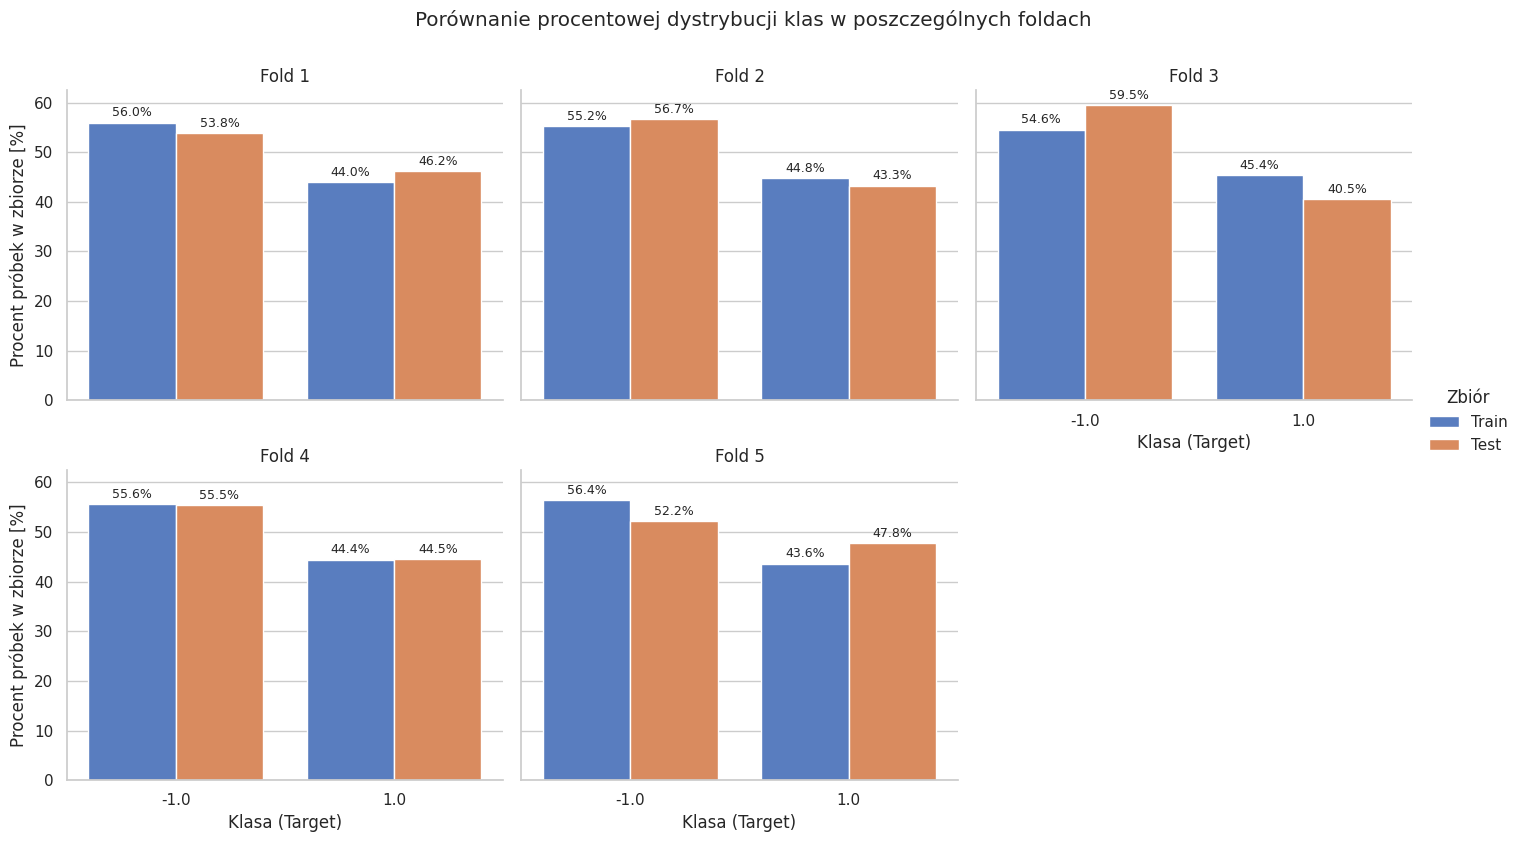

In [2]:

# --- KONFIGURACJA ---
K_FOLDS = 5
# Jeżeli Twoje foldy są zagnieżdżone w folderze głębokości, wpisz tu np. 'depth_2'
# Jeżeli są w głównym katalogu, zostaw '.'
BASE_DIR = '.' 

# Lista do przechowywania zagregowanych danych
distribution_data = []

for fold in range(1, K_FOLDS + 1):
    fold_dir = os.path.join(BASE_DIR, f'fold_{fold}')
    train_csv = os.path.join(fold_dir, 'train_data.csv')
    test_csv = os.path.join(fold_dir, 'test_data.csv')
    
    if not os.path.exists(train_csv) or not os.path.exists(test_csv):
        print(f"Brak plików dla foldu {fold}. Sprawdź ścieżki.")
        continue
        
    # Wczytywanie danych
    train_df = pd.read_csv(train_csv)
    test_df = pd.read_csv(test_csv)
    
    # Zliczanie klas
    train_counts = train_df['target'].value_counts().sort_index()
    test_counts = test_df['target'].value_counts().sort_index()
    
    # Obliczanie sum
    train_total = train_counts.sum()
    test_total = test_counts.sum()
    
    # Zapisywanie wyników dla Train
    for target_val, count in train_counts.items():
        distribution_data.append({
            'Fold': f'Fold {fold}',
            'Zbiór': 'Train',
            'Klasa (Target)': target_val,
            'Liczność': count,
            'Procent': (count / train_total) * 100
        })
        
    # Zapisywanie wyników dla Test
    for target_val, count in test_counts.items():
        distribution_data.append({
            'Fold': f'Fold {fold}',
            'Zbiór': 'Test',
            'Klasa (Target)': target_val,
            'Liczność': count,
            'Procent': (count / test_total) * 100
        })

if not distribution_data:
    print("Nie udało się załadować żadnych danych. Sprawdź strukturę folderów.")
else:
    # --- PRZYGOTOWANIE TABELI ---
    df_dist = pd.DataFrame(distribution_data)
    
    # Formatowanie kolumny procentowej do ładnego wyświetlania
    df_dist['Podsumowanie'] = df_dist.apply(
        lambda row: f"{row['Liczność']} ({row['Procent']:.1f}%)", axis=1
    )
    
    # Tworzenie tabeli przestawnej (Pivot Table) dla lepszej czytelności
    pivot_table = df_dist.pivot_table(
        index=['Fold', 'Zbiór'], 
        columns='Klasa (Target)', 
        values='Podsumowanie', 
        aggfunc='first'
    )
    
    display(Markdown("### Tabela: Dystrybucja klas w foldach (Liczność i Procent)"))
    display(pivot_table)
    
    # --- WIZUALIZACJA ---
    sns.set_theme(style="whitegrid")
    
    # Tworzenie wykresu
    g = sns.catplot(
        data=df_dist, 
        kind="bar",
        x="Klasa (Target)", 
        y="Procent", 
        hue="Zbiór", 
        col="Fold",
        col_wrap=3, 
        height=4, 
        aspect=1.2,
        palette="muted"
    )
    
    g.set_axis_labels("Klasa (Target)", "Procent próbek w zbiorze [%]")
    g.set_titles("{col_name}")
    g.fig.suptitle("Porównanie procentowej dystrybucji klas w poszczególnych foldach", y=1.05)
    
    # Dodawanie wartości procentowych nad słupkami
    for ax in g.axes.flat:
        for p in ax.patches:
            if p.get_height() > 0:
                ax.annotate(f"{p.get_height():.1f}%", 
                            (p.get_x() + p.get_width() / 2., p.get_height()), 
                            ha='center', va='center', 
                            xytext=(0, 7), 
                            textcoords='offset points',
                            fontsize=9)
                
    plt.show()